In [1]:
#Data Processing and testing the dataset
# (Testing the dataset with the first 200 CSV Files with a random sample user of 200)

# Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Step 2: Import necessary libraries
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, to_timestamp, year, month, dayofmonth, hour, minute, second, when
from pyspark.sql.types import TimestampType, DateType, StringType
import pandas as pd
from pathlib import Path
import os
import zipfile
import random

# Step 3: Initialize SparkSession
spark = SparkSession.builder \
    .appName("CDR Preprocessing") \
    .getOrCreate()

# Step 4: Define the preprocessing function
def preprocess_cdrs_using_spark(file_or_folder=None, number_of_users_to_sample=None,
                                output_csv=None, date_format='yyyyMMddHHmmss',  # Updated datetime pattern
                                debug_mode=True, loc_file=None, save_to_csv=False,
                                drop_missing_locations=True):  # Add a flag to control handling of missing locations
    """
    Perform basic preprocessing on CDR data using Spark:
    1. Rename columns
    2. Change data types
    3. Add location details
    4. Sample data for analysis
    :param file_or_folder: Path to the CDR data file or folder
    :param number_of_users_to_sample: Number of users to sample
    :param output_csv: Path to save the output CSV
    :param date_format: Format of the datetime in the CDR data
    :param debug_mode: If True, use a small sample of data for debugging
    :param loc_file: Path to the location details file
    :param save_to_csv: If True, save the output to a CSV file
    :param drop_missing_locations: If True, drop rows with missing location data; otherwise, fill with defaults
    :return: Processed DataFrame (if save_to_csv is False)
    """
    try:
        # Step 4.1: Read data with Spark
        if os.path.isdir(file_or_folder):
            # List all CSV files in the folder
            csv_files = [os.path.join(file_or_folder, f) for f in os.listdir(file_or_folder) if f.endswith('.csv')]

            # Select the first 200 CSV files for testing
            subset_files = csv_files[:200]
            print("Subset of CSV files to load (first 200 CSV files):", subset_files)

            # Load the subset of files into a Spark DataFrame
            df_list = [spark.read.csv(file, header=True, inferSchema=False) for file in subset_files]  # Set inferSchema=False
            df = df_list[0]
            for df_temp in df_list[1:]:
                df = df.union(df_temp)
        else:
            # If it's a single file, load it directly
            df = spark.read.csv(file_or_folder, header=True, inferSchema=False)  # Set inferSchema=False

        # Ensure cdrDatetime is read as a string
        df = df.withColumn("cdr datetime", col("cdr datetime").cast(StringType()))

        # Step 4.2: Print the schema to debug column names and data types
        print("Schema of the raw data:")
        df.printSchema()

        # Step 4.3: Rename columns to remove spaces and use camel case
        df2 = df.withColumnRenamed("cdr datetime", "cdrDatetime") \
                .withColumnRenamed("user_id", "phoneNumber") \
                .withColumnRenamed("last calling cellid", "cellId") \
                .withColumnRenamed("call duration", "callDuration")

        # Step 4.4: Drop the 'cdr type' column
        df3 = df2.drop("cdr type")

        # Step 4.5: Convert `cdrDatetime` to timestamp
        df4 = df3.withColumn("timestamp", to_timestamp(col("cdrDatetime"), date_format))

        # Step 4.6: Extract date-related columns (year, month, day, hour, minute, second)
        df5 = df4.withColumn("year", year(col("timestamp"))) \
                 .withColumn("month", month(col("timestamp"))) \
                 .withColumn("day", dayofmonth(col("timestamp"))) \
                 .withColumn("hour", hour(col("timestamp"))) \
                 .withColumn("minute", minute(col("timestamp"))) \
                 .withColumn("second", second(col("timestamp")))

        # Step 4.7: Remove rows with null phoneNumbers and cellId
        df6 = df5.filter(col("phoneNumber").isNotNull() & col("cellId").isNotNull())

        # Step 4.8: Fill null callDuration with a default value (e.g., 0)
        df6 = df6.withColumn("callDuration", when(col("callDuration").isNull(), 0).otherwise(col("callDuration")))

        # Step 4.9: Merge with location details using cellId
        if loc_file:
            # Read location details into a Pandas DataFrame
            dfLoc = pd.read_csv(loc_file)

            # Rename column 'cell_id' to 'cellId' in the Pandas DataFrame
            dfLoc.rename(columns={'cell_id': 'cellId'}, inplace=True)

            # Create a Spark DataFrame from the Pandas DataFrame
            sdfLoc = spark.createDataFrame(dfLoc)

            # Option 1: Drop rows with missing location data
            if drop_missing_locations:
                df7 = df6.join(sdfLoc, on="cellId", how="inner")  # Use inner join to drop rows with no matching location data
            # Option 2: Keep rows with missing location data and fill with defaults
            else:
                # Find cellId values in CDR data that are missing in the location data
                missing_cellIds = df6.select("cellId").subtract(sdfLoc.select("cellId"))
                print("cellId values missing in location data:")
                missing_cellIds.show()

                # Join the CDRs DataFrame with the location DataFrame
                df7 = df6.join(sdfLoc, on="cellId", how="left")

                # Debug: Count rows with missing site_id before transformation
                print("Rows with missing site_id before transformation:", df7.filter(col("site_id").isNull()).count())

                # Fill null values in site_id, lat, and lon
                df7 = df7.withColumn("site_id", when(col("site_id").isNull(), "S242").otherwise(col("site_id"))) \
                         .withColumn("lat", when(col("lat").isNull(), 0.0).otherwise(col("lat"))) \
                         .withColumn("lon", when(col("lon").isNull(), 0.0).otherwise(col("lon")))

                # Debug: Count rows with missing site_id after transformation
                print("Rows with missing site_id after transformation:", df7.filter(col("site_id").isNull()).count())

                # Persist the DataFrame to ensure changes are retained
                df7 = df7.cache()
        else:
            df7 = df6

        # Step 4.10: Create a list of unique user phoneNumbers
        all_users = df7.select("phoneNumber").distinct().rdd.flatMap(lambda x: x).collect()

        # Step 4.11: Randomly select the required number of users
        if number_of_users_to_sample and number_of_users_to_sample < len(all_users):
            random_user_numbers = random.sample(all_users, number_of_users_to_sample)
        else:
            random_user_numbers = all_users

        # Step 4.12: Select only the random user data
        dfu = df7.filter(col("phoneNumber").isin(random_user_numbers))

        # Step 4.13: Save to CSV if necessary
        if save_to_csv and output_csv:
            dfu.write.csv(output_csv, header=True, mode="overwrite")
            print(f"Processed data saved to: {output_csv}")
        else:
            return dfu

    except Exception as e:
        print("An error occurred during preprocessing:", e)
        raise

# Step 5: Define paths using Path from pathlib
DATA_DIR = Path("/content/drive/My Drive")

# Path to the zipped CDR dataset
cdr_zip_path = DATA_DIR / "simulated_cdrs-20250117T061050Z-002.zip"

# Path to the location details file
loc_file_path = DATA_DIR / "simulated_locs.csv"

# Path to the output CSV file
output_csv_path = DATA_DIR / "processed_cdrs.csv"

# Temporary extraction path for the CDR dataset
extract_path = Path("/content/simulated_cdrs")
os.makedirs(extract_path, exist_ok=True)  # Create the extraction folder if it doesn't exist

# Step 6: Unzip the CDR dataset
with zipfile.ZipFile(cdr_zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Locate the extracted CSV files
cdr_folder_path = extract_path / "simulated_cdrs"  # Adjust this if the folder structure is different

# Step 7: Call the preprocessing function with the first 200 csv files
dfu = preprocess_cdrs_using_spark(
    file_or_folder=str(cdr_folder_path),  # Path to the folder containing CDR files
    number_of_users_to_sample=200,  # Sample 200 users
    output_csv=str(output_csv_path),  # Path to save the output CSV
    date_format='yyyyMMddHHmmss',  # Updated datetime pattern
    debug_mode=False,  # Set to False to process the entire dataset
    loc_file=str(loc_file_path),  # Path to the location details file
    save_to_csv=True,  # Save the output to a CSV file
    drop_missing_locations=False  # Set to True to drop rows with missing location data
)

# Step 8: Stop the Spark session
spark.stop()

# Step 9: Reinitialize SparkSession to load and inspect the processed data
spark = SparkSession.builder \
    .appName("Load Processed Data") \
    .getOrCreate()

# Step 10: Load the processed data
processed_df = spark.read.csv(str(output_csv_path), header=True, inferSchema=True)

# Step 11: Show the schema of the processed data
print("Schema of the processed data:")
processed_df.printSchema()

# Step 12: Show the first 50 rows of the processed data
print("Sample processed data:")
processed_df.show(50)

# Step 13: Stop the SparkSession
spark.stop()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Subset of CSV files to load (first 200 CSV files): ['/content/simulated_cdrs/simulated_cdrs/HW2018070404393244.dat.csv', '/content/simulated_cdrs/simulated_cdrs/HW2018070101508755.dat.csv', '/content/simulated_cdrs/simulated_cdrs/HW2018070312472292.dat.csv', '/content/simulated_cdrs/simulated_cdrs/HW2018063020318436.dat.csv', '/content/simulated_cdrs/simulated_cdrs/HW2018070305081833.dat.csv', '/content/simulated_cdrs/simulated_cdrs/HW2018070419164121.dat.csv', '/content/simulated_cdrs/simulated_cdrs/HW2018070914291034.dat.csv', '/content/simulated_cdrs/simulated_cdrs/HW2018070518315516.dat.csv', '/content/simulated_cdrs/simulated_cdrs/HW2018070919251330.dat.csv', '/content/simulated_cdrs/simulated_cdrs/HW2018070406183343.dat.csv', '/content/simulated_cdrs/simulated_cdrs/HW2018070919511356.dat.csv', '/content/simulated_cdrs/simulated_cdrs/HW2018062916456770.d

In [16]:
#TASK 1:Using the whole dataset with a random sample of 7,000 users
# Step 1: Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Step 2: Import necessary libraries
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, to_timestamp, year, month, dayofmonth, hour, minute, second, when
from pyspark.sql.types import TimestampType, DateType, StringType
import pandas as pd
from pathlib import Path
import os
import zipfile
import random

# Step 3: Initialize SparkSession with increased memory allocation
spark = SparkSession.builder \
    .appName("Big data Analytics") \
    .config("spark.executor.memory", "4g") \
    .config("spark.some.config.option", "some-value") \
    .config("spark.sql.legacy.timeParserPolicy", "LEGACY") \
    .config("spark.driver.memory", "8g") \
    .getOrCreate()

# Step 4: Define the preprocessing function
def preprocess_cdrs_using_spark(file_or_folder=None, number_of_users_to_sample=None,
                                output_csv=None, date_format='yyyyMMddHHmmss',
                                debug_mode=False, loc_file=None, save_to_csv=False,
                                drop_missing_locations=False):
    """
    Perform basic preprocessing on CDR data using Spark:
    1. Rename columns
    2. Change data types
    3. Add location details
    4. Sample data for analysis
    """
    try:
        # Step 4.1: Read data with Spark
        if os.path.isdir(file_or_folder):
            # Load all CSV files at once using a wildcard
            df = spark.read.csv(os.path.join(file_or_folder, "*.csv"), header=True, inferSchema=False)
        else:
            # If it's a single file, load it directly
            df = spark.read.csv(file_or_folder, header=True, inferSchema=False)

        # Ensure cdrDatetime is read as a string
        df = df.withColumn("cdr datetime", col("cdr datetime").cast(StringType()))

        # Step 4.2: Print the schema to debug column names and data types
        print("Schema of the raw data:")
        df.printSchema()

        # Step 4.3: Rename columns to remove spaces and use camel case
        df2 = df.withColumnRenamed("cdr datetime", "cdrDatetime") \
                .withColumnRenamed("user_id", "phoneNumber") \
                .withColumnRenamed("last calling cellid", "cellId") \
                .withColumnRenamed("call duration", "callDuration")

        # Step 4.4: Drop the 'cdr type' column
        df3 = df2.drop("cdr type")

        # Step 4.5: Convert `cdrDatetime` to timestamp
        df4 = df3.withColumn("timestamp", to_timestamp(col("cdrDatetime"), date_format))

        # Step 4.6: Extract date-related columns (year, month, day, hour, minute, second)
        df5 = df4.withColumn("year", year(col("timestamp"))) \
                 .withColumn("month", month(col("timestamp"))) \
                 .withColumn("day", dayofmonth(col("timestamp"))) \
                 .withColumn("hour", hour(col("timestamp"))) \
                 .withColumn("minute", minute(col("timestamp"))) \
                 .withColumn("second", second(col("timestamp")))

        # Step 4.7: Remove rows with null phoneNumbers and cellId
        df6 = df5.filter(col("phoneNumber").isNotNull() & col("cellId").isNotNull())

        # Step 4.8: Fill null callDuration with a default value (e.g., 0)
        df6 = df6.withColumn("callDuration", when(col("callDuration").isNull(), 0).otherwise(col("callDuration")))

        # Step 4.9: Merge with location details using cellId
        if loc_file:
            # Read location details into a Pandas DataFrame
            dfLoc = pd.read_csv(loc_file)

            # Rename column 'cell_id' to 'cellId' in the Pandas DataFrame
            dfLoc.rename(columns={'cell_id': 'cellId'}, inplace=True)

            # Create a Spark DataFrame from the Pandas DataFrame
            sdfLoc = spark.createDataFrame(dfLoc)

            # Option 1: Drop rows with missing location data
            if drop_missing_locations:
                df7 = df6.join(sdfLoc, on="cellId", how="inner")
            # Option 2: Keep rows with missing location data and fill with defaults
            else:
                # Find cellId values in CDR data that are missing in the location data
                missing_cellIds = df6.select("cellId").subtract(sdfLoc.select("cellId"))
                print("cellId values missing in location data:")
                missing_cellIds.show()
                # Join the CDRs DataFrame with the location DataFrame
                df7 = df6.join(sdfLoc, on="cellId", how="left")

                # Debug: Count rows with missing site_id before TRansformation(cleaning)
                print("Rows with missing site_id before cleaning:", df7.filter(col("site_id").isNull()).count())

                # Fill null values in site_id, lat, and lon
                df7 = df7.withColumn("site_id", when(col("site_id").isNull(), "S242").otherwise(col("site_id"))) \
                         .withColumn("lat", when(col("lat").isNull(), 0.0).otherwise(col("lat"))) \
                         .withColumn("lon", when(col("lon").isNull(), 0.0).otherwise(col("lon")))

                # Debug: Count rows with missing site_id after transformation
                print("Rows with missing site_id after transformation:", df7.filter(col("site_id").isNull()).count())

                # Persist the DataFrame to ensure changes are retained
                df7 = df7.cache()
        else:
            df7 = df6

        # Step 4.10: Create a list of unique user phoneNumbers
        all_users = df7.select("phoneNumber").distinct().rdd.flatMap(lambda x: x).collect()

        # Step 4.11: Randomly select the required number of users
        if number_of_users_to_sample and number_of_users_to_sample < len(all_users):
            random_user_numbers = random.sample(all_users, number_of_users_to_sample)
        else:
            random_user_numbers = all_users

        # Step 4.12: Select only the random user data
        dfu = df7.filter(col("phoneNumber").isin(random_user_numbers))

        # Step 4.13: Save to CSV if necessary
        if save_to_csv and output_csv:
            # Save with multiple partitions for better performance
            dfu.write.csv(output_csv, header=True, mode="overwrite")
            print(f"Processed data saved to: {output_csv}")
        else:
            return dfu

    except Exception as e:
        print("An error occurred during preprocessing:", e)
        raise

# Step 5: Define paths using Path from pathlib
DATA_DIR = Path("/content/drive/My Drive")

# Path to the zipped CDR dataset
cdr_zip_path = DATA_DIR / "simulated_cdrs-20250117T061050Z-002.zip"

# Path to the location details file
loc_file_path = DATA_DIR / "simulated_locs.csv"

# Path to the output CSV file
output_csv_path = DATA_DIR / "processed_cdrs.csv"

# Temporary extraction path for the CDR dataset
extract_path = Path("/content/simulated_cdrs")
os.makedirs(extract_path, exist_ok=True)  # Create the extraction folder if it doesn't exist

# Step 6: Unzip the CDR dataset
with zipfile.ZipFile(cdr_zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Locate the extracted CSV files
cdr_folder_path = extract_path / "simulated_cdrs"  # Adjust this if the folder structure is different

# Step 7: Call the preprocessing function with the entire dataset
dfu = preprocess_cdrs_using_spark(
    file_or_folder=str(cdr_folder_path),  # Path to the folder containing CDR files
    number_of_users_to_sample=7000,  # Sample 7000 users
    output_csv=str(output_csv_path),  # Path to save the output CSV
    date_format='yyyyMMddHHmmss',  # Updated datetime pattern
    debug_mode=False,  # Set to False to process the entire dataset
    loc_file=str(loc_file_path),  # Path to the location details file
    save_to_csv=True,  # Save the output to a CSV file
    drop_missing_locations=False  # Set to True to drop rows with missing location data
)

# Step 8: Stop the Spark session
spark.stop()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Schema of the raw data:
root
 |-- cdr type: string (nullable = true)
 |-- cdr datetime: string (nullable = true)
 |-- call duration: string (nullable = true)
 |-- last calling cellid: string (nullable = true)
 |-- user_id: string (nullable = true)

cellId values missing in location data:
+-------+
| cellId|
+-------+
|20294.0|
|40117.0|
|34633.0|
|34096.0|
|40045.0|
|40472.0|
|40105.0|
|10072.0|
|40016.0|
|35811.0|
|34659.0|
|40260.0|
|35680.0|
|22127.0|
|12019.0|
|35335.0|
|20863.0|
|10278.0|
|40101.0|
|40173.0|
+-------+
only showing top 20 rows

Rows with missing site_id before cleaning: 25692432
Rows with missing site_id after transformation: 0
Processed data saved to: /content/drive/My Drive/processed_cdrs.csv


In [22]:
import pandas as pd
import os

# Path to the directory containing the CSV files
output_dir = '/content/drive/My Drive/processed_cdrs.csv'

# List all part files in the directory
part_files = [os.path.join(output_dir, f) for f in os.listdir(output_dir) if f.endswith('.csv')]

# Read all part files into a single DataFrame
processed_data = pd.concat([pd.read_csv(f) for f in part_files], ignore_index=True)

# Display the first few rows
print(processed_data.head(5))
print(processed_data.tail(5))

    cellId     cdrDatetime  callDuration          phoneNumber  \
0  22201.0  20180710195753             0  6755832695895494468   
1  40557.0  20180629195313             0  4944735968957270314   
2  20532.0  20180712200416             0  8587740159891403973   
3  20532.0  20180712195732             0  8587740159891403973   
4  20532.0  20180703195543             0   618888703666973688   

                  timestamp  year  month  day  hour  minute  second site_id  \
0  2018-07-10T19:57:53.000Z  2018      7   10    19      57      53    S242   
1  2018-06-29T19:53:13.000Z  2018      6   29    19      53      13    S242   
2  2018-07-12T20:04:16.000Z  2018      7   12    20       4      16    S242   
3  2018-07-12T19:57:32.000Z  2018      7   12    19      57      32    S242   
4  2018-07-03T19:55:43.000Z  2018      7    3    19      55      43    S242   

   lat  lon  
0  0.0  0.0  
1  0.0  0.0  
2  0.0  0.0  
3  0.0  0.0  
4  0.0  0.0  
        cellId     cdrDatetime  callDuration      

In [23]:
#Task 2 (Using the processed dataset to find the total number of days, mean and median)
import pandas as pd
import os

# Step 1: Load the processed data from the directory
output_dir = '/content/drive/My Drive/processed_cdrs.csv'

# List all part files in the directory
part_files = [os.path.join(output_dir, f) for f in os.listdir(output_dir) if f.endswith('.csv')]

# Read all part files into a single DataFrame
processed_data = pd.concat([pd.read_csv(f) for f in part_files], ignore_index=True)

# Display the first few rows and last few rows of the data
print("Processed Data Sample (First 5 Rows):")
print(processed_data.head())
print("\nProcessed Data Sample (Last 5 Rows):")
print(processed_data.tail())

# Step 2: Calculate the total number of days in the dataset
# Create a date column by combining year, month, and day
processed_data['date'] = pd.to_datetime(processed_data[['year', 'month', 'day']])

# Calculate the total number of unique days
total_days = processed_data['date'].nunique()
print(f"\nTotal number of days in the dataset: {total_days}")

# Step 3: Calculate the mean and median number of calls per user
# Group by user and count the number of calls
calls_per_user = processed_data.groupby('phoneNumber').size().reset_index(name='call_count')

# Calculate mean and median
mean_calls_per_user = calls_per_user['call_count'].mean()
median_calls_per_user = calls_per_user['call_count'].median()

print(f"\nMean number of calls per user: {mean_calls_per_user}")
print(f"Median number of calls per user: {median_calls_per_user}")

Processed Data Sample (First 5 Rows):
    cellId     cdrDatetime  callDuration          phoneNumber  \
0  22201.0  20180710195753             0  6755832695895494468   
1  40557.0  20180629195313             0  4944735968957270314   
2  20532.0  20180712200416             0  8587740159891403973   
3  20532.0  20180712195732             0  8587740159891403973   
4  20532.0  20180703195543             0   618888703666973688   

                  timestamp  year  month  day  hour  minute  second site_id  \
0  2018-07-10T19:57:53.000Z  2018      7   10    19      57      53    S242   
1  2018-06-29T19:53:13.000Z  2018      6   29    19      53      13    S242   
2  2018-07-12T20:04:16.000Z  2018      7   12    20       4      16    S242   
3  2018-07-12T19:57:32.000Z  2018      7   12    19      57      32    S242   
4  2018-07-03T19:55:43.000Z  2018      7    3    19      55      43    S242   

   lat  lon  
0  0.0  0.0  
1  0.0  0.0  
2  0.0  0.0  
3  0.0  0.0  
4  0.0  0.0  

Processed D

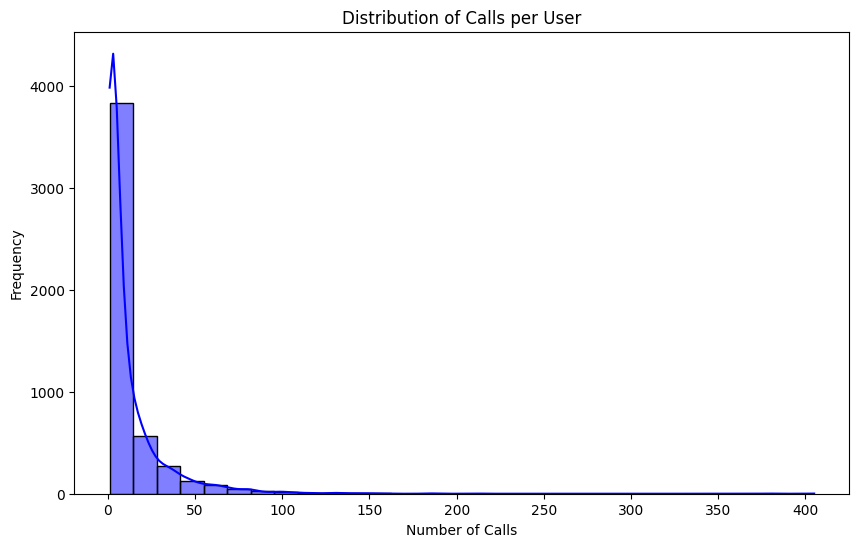

In [18]:
#Visualization of Distribution of Calls per user using Histogram
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the distribution of calls per user
plt.figure(figsize=(10, 6))
sns.histplot(calls_per_user['call_count'], bins=30, kde=True, color='blue')
plt.title('Distribution of Calls per User')
plt.xlabel('Number of Calls')
plt.ylabel('Frequency')
plt.show()

In [24]:
#Task 3:Creating and runing function to create individual user mobility attributes
import pandas as pd
import numpy as np
from math import radians, sin, cos, sqrt, atan2
import os

# Function to calculate the Haversine distance between two points
def haversine(lat1, lon1, lat2, lon2):
    """
    Calculate the great-circle distance between two points on the Earth.
    """
    # Convert latitude and longitude from degrees to radians
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])

    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat / 2) ** 2 + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))
    radius = 6371  # Earth's radius in kilometers
    return radius * c

# Function to calculate user mobility attributes
def calculate_user_mobility_attributes(df):
    """
    Calculate mobility attributes for each user:
    - Number of unique locations visited per day
    - Average number of locations visited per day
    - Radius of gyration (Rg)
    """
    # Step 1: Check if required columns exist
    required_columns = ['phoneNumber', 'date', 'cellId', 'lat', 'lon']
    for col in required_columns:
        if col not in df.columns:
            raise KeyError(f"Column '{col}' is missing in the DataFrame.")

    # Step 2: Filter out rows with invalid location data (lat = 0, lon = 0)
    df = df[(df['lat'] != 0.0) & (df['lon'] != 0.0)]

    # Step 3: Group by user and date to calculate unique locations per day
    user_mobility = df.groupby(['phoneNumber', 'date']).agg(
        num_locs=('cellId', 'nunique')  # Number of unique locations per day
    ).reset_index()

    # Step 4: Calculate average number of locations visited per day
    avg_locs_per_user = user_mobility.groupby('phoneNumber').agg(
        avg_locs_per_day=('num_locs', 'mean')  # Average number of locations per day
    ).reset_index()

    # Step 5: Calculate radius of gyration (Rg) for each user
    def calculate_rg(user_df):
        # Calculate center of mass (mean latitude and longitude)
        lat_mean = user_df['lat'].mean()
        lon_mean = user_df['lon'].mean()

        # Calculate distance from each location to the center of mass
        user_df['distance'] = user_df.apply(
            lambda row: haversine(row['lat'], row['lon'], lat_mean, lon_mean), axis=1
        )
        # Calculate Rg
        rg = np.sqrt((user_df['distance'] ** 2).mean())
        return rg

    # Group by user and calculate Rg
    user_rg = df.groupby('phoneNumber', group_keys=False).apply(calculate_rg, include_groups=False).reset_index(name='Rg')

    # Step 6: Merge all user attributes
    user_attributes = avg_locs_per_user.merge(user_rg, on='phoneNumber')

    return user_attributes

# Step 7: Load the processed data
output_dir = '/content/drive/My Drive/processed_cdrs.csv'
part_files = [os.path.join(output_dir, f) for f in os.listdir(output_dir) if f.endswith('.csv')]
processed_data = pd.concat([pd.read_csv(f) for f in part_files], ignore_index=True)

# Step 8: Create the 'date' column if it doesn't exist
if 'date' not in processed_data.columns:
    processed_data['date'] = pd.to_datetime(processed_data[['year', 'month', 'day']])

# Step 9: Calculate user mobility attributes
try:
    user_attributes = calculate_user_mobility_attributes(processed_data)
except KeyError as e:
    print(e)
    print("Please ensure the required columns are present in the dataset.")
else:
    # Step 10: Save user attributes to a CSV file
    output_path = '/content/drive/My Drive/user_mobility_attributes.csv'

    # Check if the path exists and is a directory
    if os.path.exists(output_path) and os.path.isdir(output_path):
        # Delete the directory if it exists
        import shutil
        shutil.rmtree(output_path)
        print(f"Deleted directory: {output_path}")

    # Save the user attributes to a CSV file
    user_attributes.to_csv(output_path, index=False)
    print(f"User mobility attributes saved to: {output_path}")

    # Step 11: Display the first few rows of the user attributes
    print("\nUser Mobility Attributes:")
    print(user_attributes.head(5))
    print(user_attributes.tail(5))

User mobility attributes saved to: /content/drive/My Drive/user_mobility_attributes.csv

User Mobility Attributes:
         phoneNumber  avg_locs_per_day            Rg
0    463598032860099          1.000000  0.000000e+00
1   2953869775419274          1.000000  0.000000e+00
2   8477847193189018          1.777778  1.063303e+00
3   9307326304170638          1.000000  7.217597e-13
4  11515072959819651          1.142857  0.000000e+00
              phoneNumber  avg_locs_per_day         Rg
3587  9209409313187646680          1.000000   0.000000
3588  9209623801120099998          1.000000   0.000000
3589  9211144931327670185          2.076923  10.080134
3590  9217237876021413493          2.000000   0.732509
3591  9219086706180932635          1.000000   1.012242


User mobility attributes loaded successfully.
Columns in the DataFrame: ['phoneNumber', 'avg_locs_per_day', 'Rg']
Correlation between Rg and avg_locs_per_day: 0.13


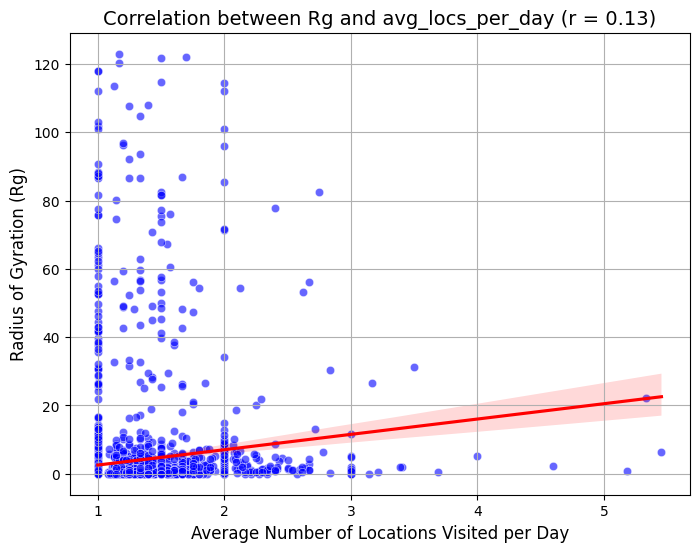

In [20]:
#Visualization of the Correlation plot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Step 1: Load the user mobility attributes
output_path = '/content/drive/My Drive/user_mobility_attributes.csv'
try:
    user_attributes = pd.read_csv(output_path)
    print("User mobility attributes loaded successfully.")
    print("Columns in the DataFrame:", user_attributes.columns.tolist())
except FileNotFoundError:
    print(f"Error: The file '{output_path}' does not exist.")
    exit()

# Step 2: Check if required columns exist
required_columns = ['avg_locs_per_day', 'Rg']  # Updated column name to 'Rg'
missing_columns = [col for col in required_columns if col not in user_attributes.columns]

if missing_columns:
    print(f"Error: The following columns are missing in the DataFrame: {missing_columns}")
    print("Please ensure the 'calculate_user_mobility_attributes' function generated these columns.")
    exit()

# Step 3: Calculate the correlation coefficient
try:
    correlation, p_value = pearsonr(user_attributes['avg_locs_per_day'], user_attributes['Rg'])  # Updated column name to 'Rg'
    print(f"Correlation between Rg and avg_locs_per_day: {correlation:.2f}")
except KeyError as e:
    print(f"Error: {e}")
    print("Please ensure the required columns are present in the DataFrame.")
    exit()

# Step 4: Create a scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x='avg_locs_per_day', y='Rg', data=user_attributes, alpha=0.6, color='blue')  # Updated column name to 'Rg'

# Add a regression line
sns.regplot(x='avg_locs_per_day', y='Rg', data=user_attributes, scatter=False, color='red')  # Updated column name to 'Rg'

# Add title and labels
plt.title(f'Correlation between Rg and avg_locs_per_day (r = {correlation:.2f})', fontsize=14)  # Updated column name to 'Rg'
plt.xlabel('Average Number of Locations Visited per Day', fontsize=12)
plt.ylabel('Radius of Gyration (Rg)', fontsize=12)  # Updated column name to 'Rg'

# Display the plot
plt.grid(True)
plt.show()

User mobility attributes loaded successfully.
Columns in the DataFrame: ['phoneNumber', 'avg_locs_per_day', 'Rg']
Slope: 4.49, Intercept: -1.95
R-squared: 0.02


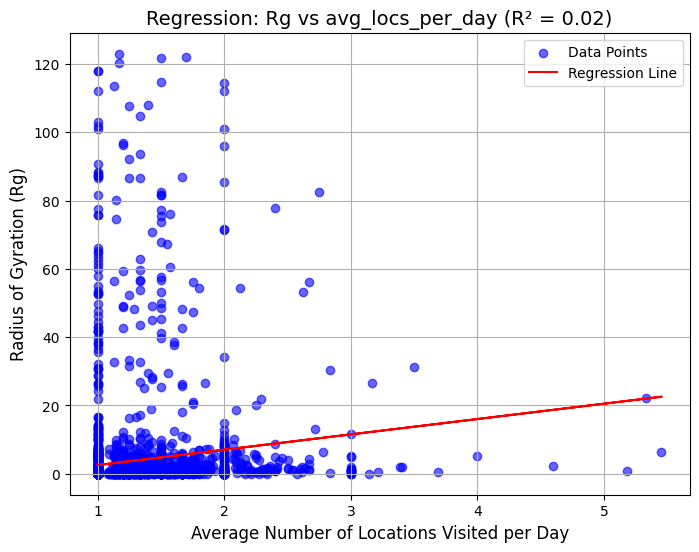

In [21]:
#Additional Visualization using Regression
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress

# Step 1: Load the user mobility attributes
output_path = '/content/drive/My Drive/user_mobility_attributes.csv'
try:
    user_attributes = pd.read_csv(output_path)
    print("User mobility attributes loaded successfully.")
    print("Columns in the DataFrame:", user_attributes.columns.tolist())
except FileNotFoundError:
    print(f"Error: The file '{output_path}' does not exist.")
    exit()

# Step 2: Check if required columns exist
required_columns = ['avg_locs_per_day', 'Rg']
missing_columns = [col for col in required_columns if col not in user_attributes.columns]

if missing_columns:
    print(f"Error: The following columns are missing in the DataFrame: {missing_columns}")
    print("Please ensure the 'calculate_user_mobility_attributes' function generated these columns.")
    exit()

# Step 3: Calculate the regression line
x = user_attributes['avg_locs_per_day']  # Independent variable
y = user_attributes['Rg']  # Dependent variable

# Perform linear regression
slope, intercept, r_value, p_value, std_err = linregress(x, y)
print(f"Slope: {slope:.2f}, Intercept: {intercept:.2f}")
print(f"R-squared: {r_value**2:.2f}")

# Step 4: Create a scatter plot with the regression line
plt.figure(figsize=(8, 6))

# Plot the scatter points
plt.scatter(x, y, alpha=0.6, color='blue', label='Data Points')

# Plot the regression line
regression_line = slope * x + intercept
plt.plot(x, regression_line, color='red', label='Regression Line')

# Add title and labels
plt.title(f'Regression: Rg vs avg_locs_per_day (R² = {r_value**2:.2f})', fontsize=14)
plt.xlabel('Average Number of Locations Visited per Day', fontsize=12)
plt.ylabel('Radius of Gyration (Rg)', fontsize=12)

# Add a legend
plt.legend()

# Display the plot
plt.grid(True)
plt.show()